## FFT Benchmark

Benchmark clesperanto FFT (with potentially different back-ends) 

First Iteration of notebook does cupy -- TODO:  clesperanto

Size: 1010x1010, Smooth Size: 1024, Avg Time: 0.000069 seconds, Avg Time Smooth: 0.000046 seconds
Size: 1011x1011, Smooth Size: 1024, Avg Time: 0.000298 seconds, Avg Time Smooth: 0.000036 seconds
Size: 1012x1012, Smooth Size: 1024, Avg Time: 0.000075 seconds, Avg Time Smooth: 0.000033 seconds
Size: 1013x1013, Smooth Size: 1024, Avg Time: 0.000380 seconds, Avg Time Smooth: 0.000033 seconds
Size: 1014x1014, Smooth Size: 1024, Avg Time: 0.000233 seconds, Avg Time Smooth: 0.000033 seconds
Size: 1015x1015, Smooth Size: 1024, Avg Time: 0.000055 seconds, Avg Time Smooth: 0.000041 seconds
Size: 1016x1016, Smooth Size: 1024, Avg Time: 0.000351 seconds, Avg Time Smooth: 0.000035 seconds
Size: 1017x1017, Smooth Size: 1024, Avg Time: 0.000062 seconds, Avg Time Smooth: 0.000033 seconds
Size: 1018x1018, Smooth Size: 1024, Avg Time: 0.000537 seconds, Avg Time Smooth: 0.000034 seconds
Size: 1019x1019, Smooth Size: 1024, Avg Time: 0.000300 seconds, Avg Time Smooth: 0.000034 seconds
Size: 1020x1020, Smo

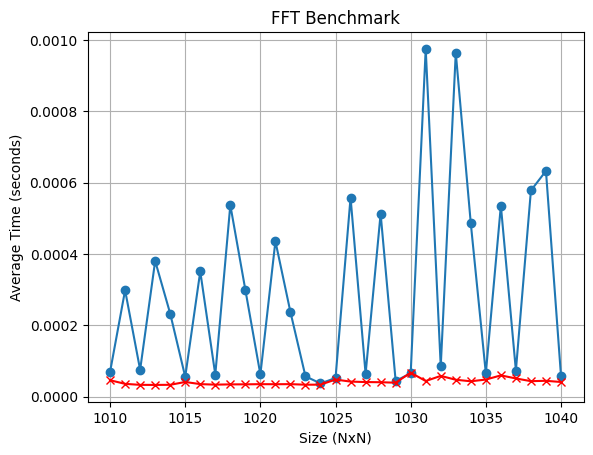

In [15]:
import cupy as cp
import time
from fft_test_helper import get_next_smooth, pad

# Function to benchmark FFT
def benchmark_fft(min_size=100, max_size=150, n=10):
    sizes = range(min_size, max_size + 1)
    times = []
    times_smooth = []

    for size in sizes:
        # Create a random 2D array of the given size
        x = cp.random.random((size, size)).astype(cp.float32)
        next_smooth = get_next_smooth([size, size])
        x_padded, _ = pad(x, next_smooth, "constant")
        
        # Perform FFT n times and measure the time taken
        start_time = time.time()
        for _ in range(n):
            _ = cp.fft.fft2(x)
        end_time = time.time()

        start_time_smooth = time.time()
        for _ in range(n):
            _ = cp.fft.fft2(x_padded)
        end_time_smooth = time.time()
        
        # Calculate the average time per FFT
        avg_time = (end_time - start_time) / n
        avg_time_smooth = (end_time_smooth - start_time_smooth) / n
        times.append(avg_time)
        times_smooth.append(avg_time_smooth)
        print(f"Size: {size}x{size}, Smooth Size: {next_smooth[0]}, Avg Time: {avg_time:.6f} seconds, Avg Time Smooth: {avg_time_smooth:.6f} seconds")

    return sizes, times, times_smooth

# Run the benchmark
sizes, times, times_smooth = benchmark_fft(1010, 1040)

# Plot the results
import matplotlib.pyplot as plt

plt.plot(sizes, times, marker='o')
plt.plot(sizes, times_smooth, marker='x', color='r')
plt.xlabel('Size (NxN)')
plt.ylabel('Average Time (seconds)')
plt.title('FFT Benchmark')
plt.grid(True)
plt.show()